# Day 4: Explainability & Calibration

Make models trustworthy through SHAP analysis, probability calibration, and threshold optimization.

## Objectives
1. **SHAP Explainability**: Understand which features drive predictions
2. **Model Calibration**: Ensure predicted probabilities reflect true likelihood
3. **Threshold Optimization**: Find optimal decision boundary using business costs

## Model Selection
This notebook automatically loads the **best model from Day 3** (XGBoost Balanced) via MLflow.
- **No retraining needed**: Model loaded in seconds
- **Consistent results**: Uses exact model from Day 3 experiments
- **Automatic fallback**: Trains XGBoost if MLflow unavailable

## Setup and Configuration

In [23]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.insert(0, str(Path.cwd()))

from data_loader import load_and_validate_data, stratified_split
from modeling import get_model
from evaluation import (
    compute_metrics,
    calibrate_model,
    compute_calibration_metrics,
    plot_reliability_curve,
    compare_calibration
)
from utils import (
    calculate_business_cost,
    find_optimal_threshold,
    plot_cost_curve,
    print_threshold_summary,
    BUSINESS_COSTS
)

import mlflow
import mlflow.sklearn
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# Load environment variables
load_dotenv()

# Configuration
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI', './mlruns')
MLFLOW_EXPERIMENT_NAME = 'telco-churn-day4-trustworthy'
RANDOM_STATE = int(os.getenv('RANDOM_STATE', 42))

# Setup MLflow
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
print(f"MLflow experiment: {MLFLOW_EXPERIMENT_NAME}\n")

MLflow tracking URI: ./mlruns
MLflow experiment: telco-churn-day4-trustworthy



In [60]:
# Load and split data
data_path = Path.cwd().parent / "data" / "telco-customer-churn-by-IBM.csv"
df = load_and_validate_data(str(data_path))
train_df, test_df = stratified_split(df, test_size=0.2, random_state=RANDOM_STATE)

X_train, y_train = train_df.drop('Churn', axis=1), train_df['Churn']
X_test, y_test = test_df.drop('Churn', axis=1), test_df['Churn']

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Create plots directory
plots_dir = Path('../deliverables/plots/day4')
plots_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots directory: {plots_dir}")

Data checksum: 0f9de68e012bd3aed5fa7cdc9fc421af
 Loaded: 7043 rows, Churn rate: 26.5%
Train: 5634 (26.5% churn)
Test:  1409 (26.5% churn)
Train set: (5634, 19)
Test set: (1409, 19)
Plots directory: ..\deliverables\plots\day4


## Load Best Model from Day 3

We'll load the best model from Day 3 (XGBoost) directly from MLflow to avoid retraining.

## Helper Functions for Model Loading

In [61]:
def load_best_model_from_mlflow(experiment_name='telco-churn-nested-cv', use_winner_tag=True):
    """
    Load the best model from Day 3 MLflow experiment.
    
    Args:
        experiment_name: Name of the MLflow experiment
        use_winner_tag: If True, load from Day3_BEST_* run. If False, find by lowest cost.
    
    Returns:
        tuple: (model, model_name, run_info)
    """
    client = mlflow.tracking.MlflowClient()
    
    # Get experiment
    experiment = client.get_experiment_by_name(experiment_name)
    if not experiment:
        raise ValueError(f"Experiment '{experiment_name}' not found. Run day3_pipeline.py first.")
    
    if use_winner_tag:
        # Find the WINNER run (Day3_BEST_*)
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            filter_string="tags.status = 'WINNER'",
            order_by=["start_time DESC"],
            max_results=1
        )
        
        if not runs:
            print("No WINNER run found. Searching by lowest cost...")
            use_winner_tag = False
        else:
            best_run = runs[0]
            model_name = best_run.data.tags.get('model_name', 'unknown')
            print(f"   Found WINNER run: {best_run.info.run_name}")
            print(f"   Model: {model_name}")
            print(f"   Cost: ${best_run.data.metrics.get('business_cost_total', 0):,.0f}")
            print(f"   FN: {int(best_run.data.metrics.get('confusion_fn_count', 0))}")
    
    if not use_winner_tag:
        # Find run with lowest business cost
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            filter_string="tags.day = 'day3' AND tags.task = 'nested_cv_hyperparameter_tuning'",
            order_by=["metrics.business_cost_total ASC"],
            max_results=1
        )
        
        if not runs:
            raise ValueError("No Day 3 runs found. Run day3_pipeline.py first.")
        
        best_run = runs[0]
        model_name = best_run.data.params.get('model_name', 'unknown')
        print(f"  Found best model by cost: {model_name}")
        print(f"   Cost: ${best_run.data.metrics.get('business_cost_total', 0):,.0f}")
        print(f"   FN: {int(best_run.data.metrics.get('confusion_fn_count', 0))}")
    
    # Load model
    model_uri = f"runs:/{best_run.info.run_id}/model"
    model = mlflow.sklearn.load_model(model_uri)
    
    print(f"   Loaded from: {model_uri}")
    
    return model, model_name, best_run.info

# Try to load from MLflow first, fallback to training if not available
try:
    print("Attempting to load best model from Day 3 MLflow experiment...")
    model, model_name, run_info = load_best_model_from_mlflow()
    print(f"\nModel loaded successfully from MLflow (no training needed)")
except Exception as e:
    print(f"\nCould not load from MLflow: {str(e)}")
    print("Falling back to training xgboost_balanced model...")
    model_name = 'xgboost_balanced'
    model = get_model(model_name)
    model.fit(X_train, y_train)
    print(f"Model trained: {model_name}")

Attempting to load best model from Day 3 MLflow experiment...
   Found WINNER run: Day3_BEST_xgboost_balanced_winner
   Model: xgboost_balanced
   Cost: $7,310
   FN: 18


   Loaded from: runs:/ea44734a8aa743a9b6c68300004e6acb/model

Model loaded successfully from MLflow (no training needed)


In [62]:
# Get baseline predictions
y_pred_baseline = model.predict(X_test)
y_proba_baseline = model.predict_proba(X_test)[:, 1]
baseline_metrics = compute_metrics(y_test.values, y_pred_baseline, y_proba_baseline)
baseline_cost = calculate_business_cost(y_test.values, y_pred_baseline)

print(f"\nBaseline Performance (threshold=0.5):")
print(f"  Model: {model_name}")
print(f"  PR-AUC: {baseline_metrics['pr_auc']:.4f}")
print(f"  Total Cost: ${baseline_cost['total_cost']:,}")
print(f"  FN: {baseline_cost['false_negatives']} | FP: {baseline_cost['false_positives']}")


Baseline Performance (threshold=0.5):
  Model: xgboost_balanced
  PR-AUC: 0.6128
  Total Cost: $7,310
  FN: 18 | FP: 551


## 1. SHAP Explainability Analysis

Understand which features drive churn predictions.

In [63]:
# Get the classifier from pipeline
classifier = model.named_steps['classifier']

# Get preprocessed data
X_train_preprocessed = model.named_steps['preprocessor'].transform(X_train)
X_test_preprocessed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

print(f"Preprocessed data shape: {X_test_preprocessed.shape}")
print(f"Number of features: {len(feature_names)}")

Preprocessed data shape: (1409, 30)
Number of features: 30


In [64]:
# Initialize SHAP explainer (LinearExplainer for Logistic Regression)
print(f"Initializing SHAP explainer...")

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

if 'XGB' in str(type(classifier)):
    # TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(classifier, X_train_preprocessed)
    shap_values = explainer.shap_values(X_test_preprocessed)
elif 'RandomForest' in str(type(classifier)):
    # TreeExplainer for RandomForest
    explainer = shap.TreeExplainer(classifier, X_train_preprocessed)
    shap_values = explainer.shap_values(X_test_preprocessed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Positive class
else:
    # LinearExplainer for Logistic Regression (deterministic)
    explainer = shap.LinearExplainer(classifier, X_train_preprocessed)
    shap_values = explainer.shap_values(X_test_preprocessed)

print(f"SHAP values computed for {X_test_preprocessed.shape[0]} test samples")
print(f"Note: SHAP values are deterministic for tree models with the same data")

Initializing SHAP explainer...
SHAP values computed for 1409 test samples
Note: SHAP values are deterministic for tree models with the same data


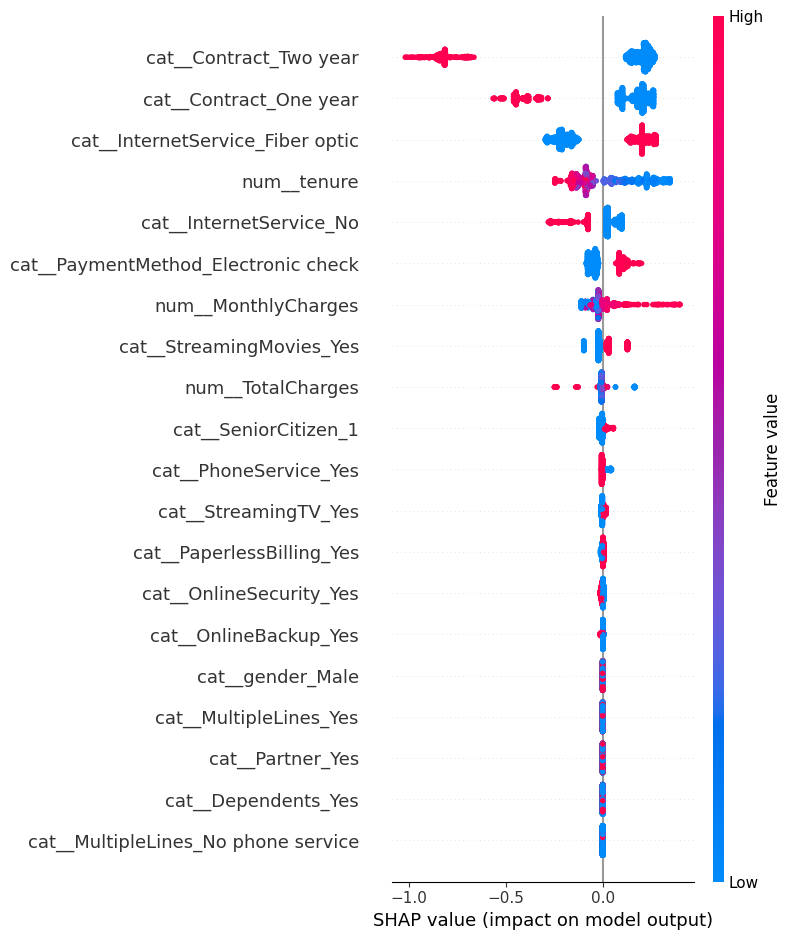

Saved: ..\deliverables\plots\day4\xgboost_balanced_shap_summary.png


In [65]:
# Plot SHAP Summary (Feature Importance)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, show=False)
plt.tight_layout()
summary_plot_path = plots_dir / f'{model_name}_shap_summary.png'
plt.savefig(summary_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {summary_plot_path}")

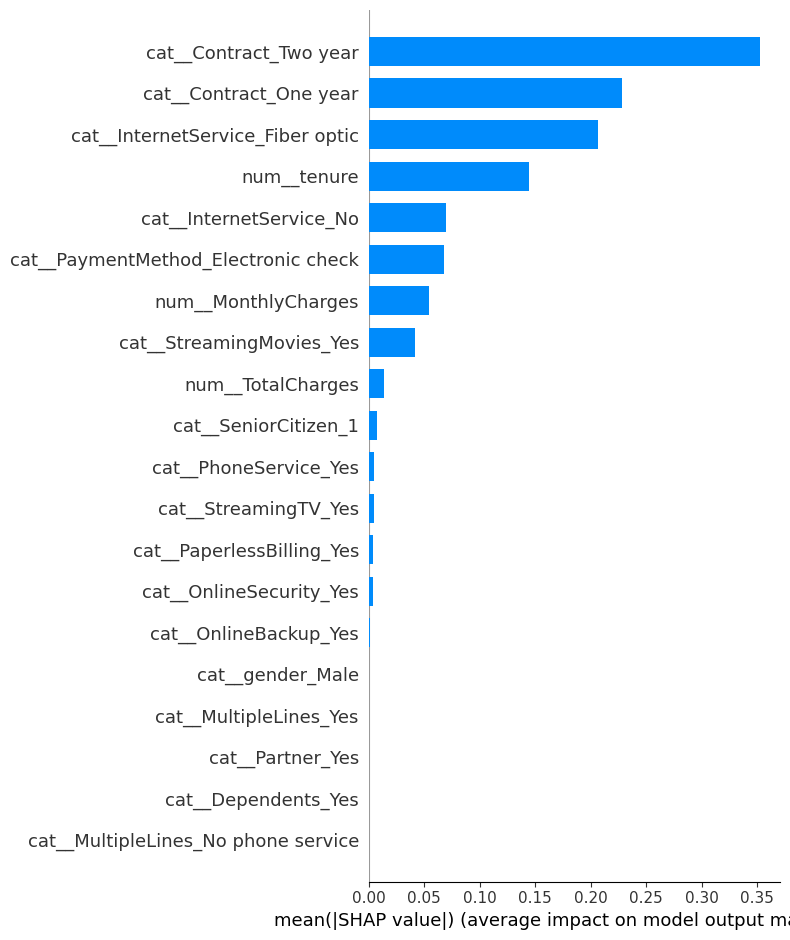

Saved: ..\deliverables\plots\day4\xgboost_balanced_shap_importance.png


In [66]:
# Plot SHAP Feature Importance Bar
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.tight_layout()
bar_plot_path = plots_dir / f'{model_name}_shap_importance.png'
plt.savefig(bar_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {bar_plot_path}")

In [67]:
# Get top features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:10]
top_features = [(feature_names[i], mean_abs_shap[i]) for i in top_indices]

print(f"Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(top_features, 1):
    print(f"  {i:2d}. {feature:40s} | Mean|SHAP|: {importance:.4f}")

Top 10 Most Important Features:
   1. cat__Contract_Two year                   | Mean|SHAP|: 0.3529
   2. cat__Contract_One year                   | Mean|SHAP|: 0.2278
   3. cat__InternetService_Fiber optic         | Mean|SHAP|: 0.2070
   4. num__tenure                              | Mean|SHAP|: 0.1444
   5. cat__InternetService_No                  | Mean|SHAP|: 0.0696
   6. cat__PaymentMethod_Electronic check      | Mean|SHAP|: 0.0682
   7. num__MonthlyCharges                      | Mean|SHAP|: 0.0540
   8. cat__StreamingMovies_Yes                 | Mean|SHAP|: 0.0414
   9. num__TotalCharges                        | Mean|SHAP|: 0.0141
  10. cat__SeniorCitizen_1                     | Mean|SHAP|: 0.0075


## 2. Model Calibration

Ensure predicted probabilities reflect true likelihood of churn.

In [68]:
from sklearn.model_selection import train_test_split
print("PROPER CALIBRATION SETUP: Splitting train data to avoid leakage")

X_train_proper, X_calib, y_train_proper, y_calib = train_test_split(
    X_train, y_train, 
    test_size=0.25,  # 25% for calibration
    stratify=y_train, 
    random_state=RANDOM_STATE  # Use consistent random state for reproducibility
)

print(f"\nTraining data split:")
print(f"   Original train set:     {X_train.shape[0]:,} samples")
print(f"   → Train proper (75%):   {X_train_proper.shape[0]:,} samples (for base model)")
print(f"   → Calibration (25%):    {X_calib.shape[0]:,} samples (held-out for calibration)")
print(f"\n   Churn rate - train_proper: {y_train_proper.mean():.1%}")
print(f"   Churn rate - calibration:  {y_calib.mean():.1%}")

PROPER CALIBRATION SETUP: Splitting train data to avoid leakage

Training data split:
   Original train set:     5,634 samples
   → Train proper (75%):   4,225 samples (for base model)
   → Calibration (25%):    1,409 samples (held-out for calibration)

   Churn rate - train_proper: 26.5%
   Churn rate - calibration:  26.5%


In [69]:
# Train a fresh base model on train_proper ONLY
print("STEP 2: Training base model on train_proper only")

from sklearn.base import clone

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Clone the original model to get a fresh unfitted copy
model_for_calib = clone(model)
model_for_calib.fit(X_train_proper, y_train_proper)

print("\n Base model trained on train_proper (4,225 samples)")
print("   This model has NEVER seen the calibration holdout data")
print(f"   Random state: {RANDOM_STATE} (for reproducibility)")

STEP 2: Training base model on train_proper only

 Base model trained on train_proper (4,225 samples)
   This model has NEVER seen the calibration holdout data
   Random state: 42 (for reproducibility)


In [70]:
# Calibrate using the CORRECTED method (cv='prefit')
print("Calibration with cv='prefit' on held-out calibration set")

# Proper calibration - uses held-out calibration data
model_proper_platt = calibrate_model(model_for_calib, X_calib, y_calib, method='sigmoid')
model_proper_isotonic = calibrate_model(model_for_calib, X_calib, y_calib, method='isotonic')

print("\n Proper Calibration Complete:")
print("   - Base model: Trained on train_proper (4,225 samples)")
print("   - Calibration: Applied on held-out X_calib (1,409 samples)")
print("   - Method: cv='prefit' prevents refitting and data leakage")

# Get predictions on test set using properly calibrated models
y_proba_test_proper_platt = model_proper_platt.predict_proba(X_test)[:, 1]
y_proba_test_proper_isotonic = model_proper_isotonic.predict_proba(X_test)[:, 1]
y_proba_test_proper_uncal = model_for_calib.predict_proba(X_test)[:, 1]

print("\nTest predictions generated")

Calibration with cv='prefit' on held-out calibration set

 Proper Calibration Complete:
   - Base model: Trained on train_proper (4,225 samples)
   - Calibration: Applied on held-out X_calib (1,409 samples)
   - Method: cv='prefit' prevents refitting and data leakage

Test predictions generated


In [71]:
# Compare calibration metrics: Proper vs OLD Leaky approach
proper_platt_metrics = compute_calibration_metrics(y_test.values, y_proba_test_proper_platt)
proper_isotonic_metrics = compute_calibration_metrics(y_test.values, y_proba_test_proper_isotonic)
proper_uncal_metrics = compute_calibration_metrics(y_test.values, y_proba_test_proper_uncal)

print("COMPARISON: Proper Calibration (No Leakage) vs Test Set")
print(f"\n{'Method':<25} {'Brier Score':<15} {'ECE':<10}")
print(f"{'Uncalibrated':<25} {proper_uncal_metrics['brier_score']:<15.4f} {proper_uncal_metrics['ece']:<10.4f}")
print(f"{'Platt (sigmoid)':<25} {proper_platt_metrics['brier_score']:<15.4f} {proper_platt_metrics['ece']:<10.4f}")
print(f"{'Isotonic':<25} {proper_isotonic_metrics['brier_score']:<15.4f} {proper_isotonic_metrics['ece']:<10.4f}")

print("\n  Interpretation:")
print("   - Lower Brier Score = Better calibrated probabilities")
print("   - Lower ECE (Expected Calibration Error) = Better calibration")
print("   - These metrics reflect TRUE generalization (no data leakage)")

COMPARISON: Proper Calibration (No Leakage) vs Test Set

Method                    Brier Score     ECE       
Uncalibrated              0.2379          0.2961    
Platt (sigmoid)           0.1437          0.0253    
Isotonic                  0.1427          0.0334    

  Interpretation:
   - Lower Brier Score = Better calibrated probabilities
   - Lower ECE (Expected Calibration Error) = Better calibration
   - These metrics reflect TRUE generalization (no data leakage)


In [72]:
# Select best calibration method based on proper calibration metrics
if proper_platt_metrics['brier_score'] < proper_isotonic_metrics['brier_score']:
    best_method = 'platt'
    best_model = model_proper_platt
    best_proba = y_proba_test_proper_platt
    print(f"\n✅ Best calibration method: Platt Scaling (Sigmoid)")
    print(f"   Brier Score: {proper_platt_metrics['brier_score']:.4f}")
    print(f"   ECE: {proper_platt_metrics['ece']:.4f}")
else:
    best_method = 'isotonic'
    best_model = model_proper_isotonic
    best_proba = y_proba_test_proper_isotonic
    print(f"\n✅ Best calibration method: Isotonic Regression")
    print(f"   Brier Score: {proper_isotonic_metrics['brier_score']:.4f}")
    print(f"   ECE: {proper_isotonic_metrics['ece']:.4f}")

print(f"\nThis model will be used for threshold optimization and deployment")


✅ Best calibration method: Isotonic Regression
   Brier Score: 0.1427
   ECE: 0.0334

This model will be used for threshold optimization and deployment


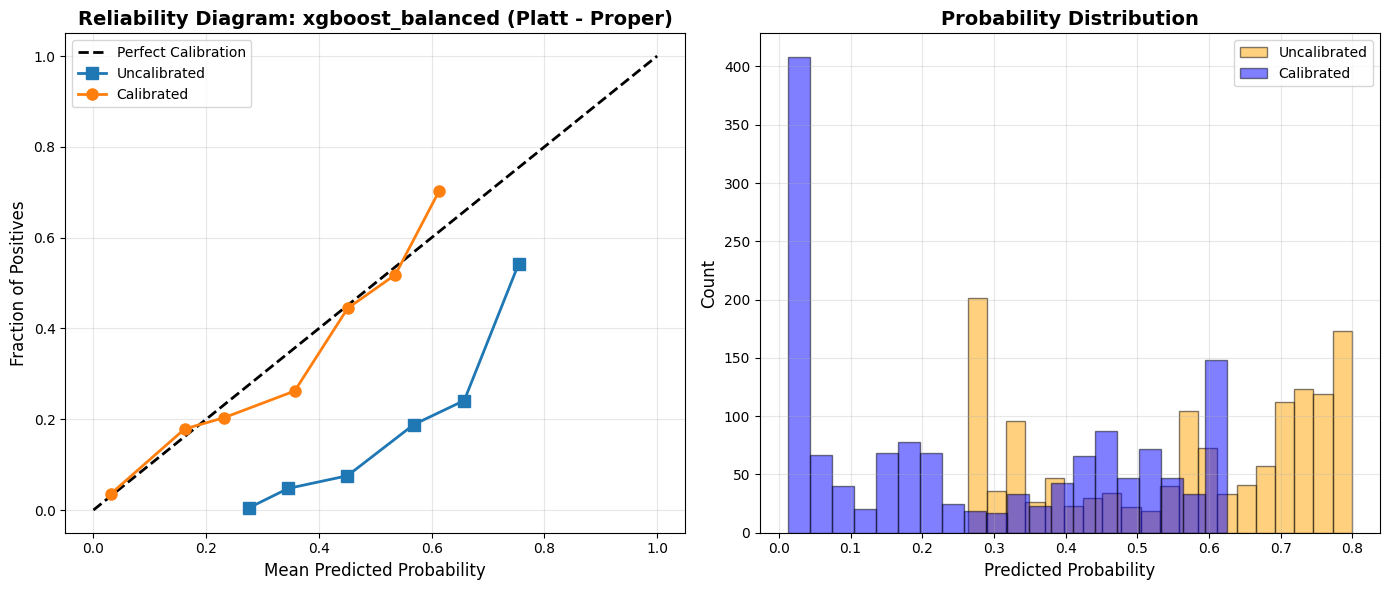

Saved: ..\deliverables\plots\day4\xgboost_balanced_calibration_platt_proper.png


In [73]:
# Plot reliability curves - Platt (Proper Calibration)
reliability_fig_platt = plot_reliability_curve(
    y_test.values, y_proba_test_proper_uncal, y_proba_test_proper_platt,
    model_name=f"{model_name} (Platt - Proper)",
    save_path=plots_dir / f'{model_name}_calibration_platt_proper.png'
)
plt.show()
print(f"Saved: {plots_dir / f'{model_name}_calibration_platt_proper.png'}")

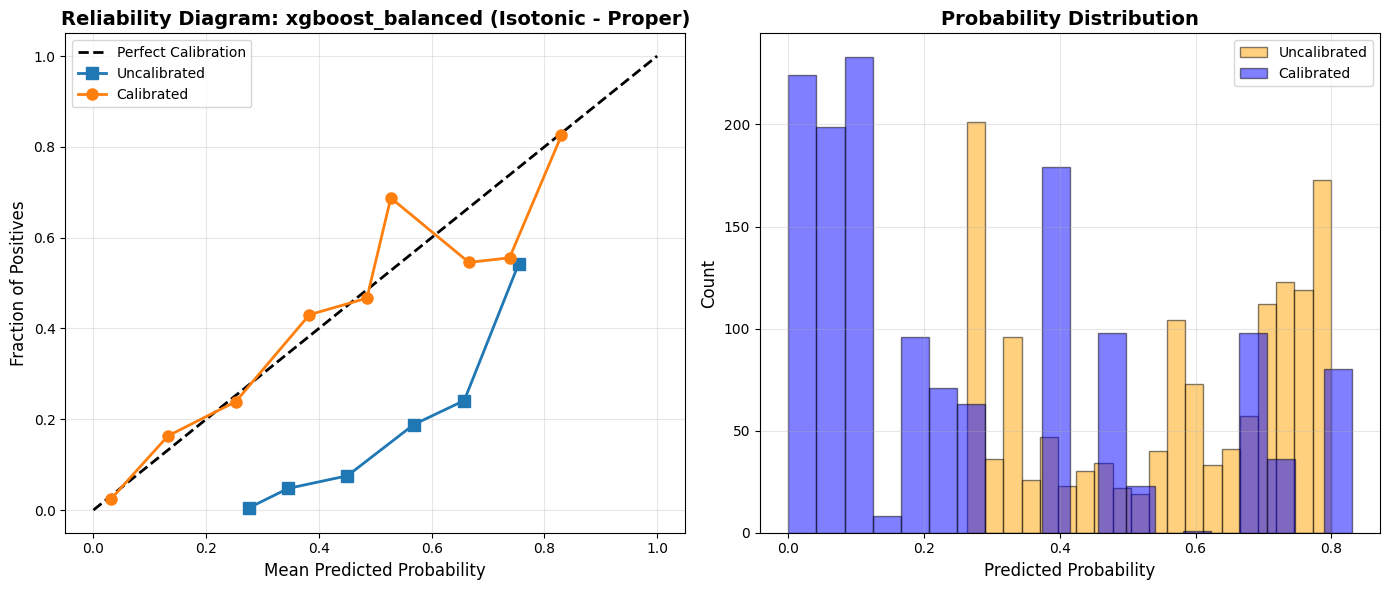

Saved: ..\deliverables\plots\day4\xgboost_balanced_calibration_isotonic_proper.png


In [74]:
# Plot reliability curves - Isotonic (Proper Calibration)
reliability_fig_isotonic = plot_reliability_curve(
    y_test.values, y_proba_test_proper_uncal, y_proba_test_proper_isotonic,
    model_name=f"{model_name} (Isotonic - Proper)",
    save_path=plots_dir / f'{model_name}_calibration_isotonic_proper.png'
)
plt.show()
print(f"Saved: {plots_dir / f'{model_name}_calibration_isotonic_proper.png'}")

## 3. Threshold Optimization

Find optimal decision boundary using business costs (FN=$100, FP=$10).

In [75]:
# Business cost context
print(f"Business Cost Context:")
print(f"  False Negative (Missed Churn): ${BUSINESS_COSTS['false_negative_cost']}")
print(f"  False Positive (Wasted Effort): ${BUSINESS_COSTS['false_positive_cost']}")
print(f"  Cost Ratio: {BUSINESS_COSTS['false_negative_cost'] / BUSINESS_COSTS['false_positive_cost']:.0f}:1")

Business Cost Context:
  False Negative (Missed Churn): $100
  False Positive (Wasted Effort): $10
  Cost Ratio: 10:1


Threshold Optimization on Uncalibrated Probabilities


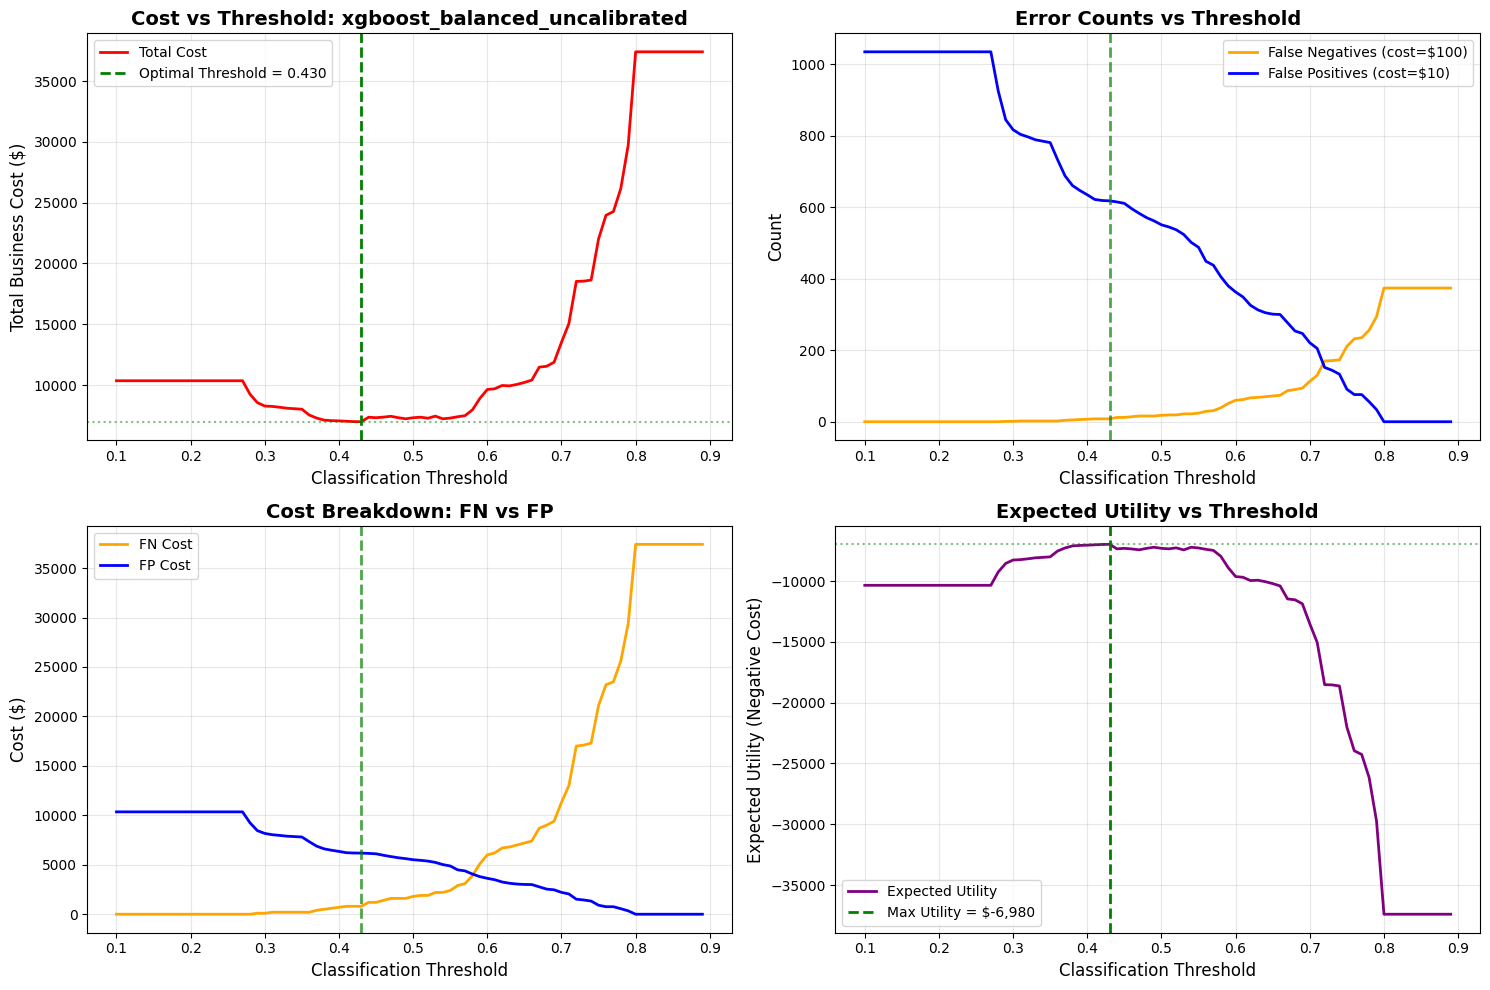

Saved: ..\deliverables\plots\day4\xgboost_balanced_uncalibrated_cost_curve.png

THRESHOLD OPTIMIZATION SUMMARY

Optimal Threshold: 0.430
  Total Cost: $6,980
  False Negatives: 8
  False Positives: 618

Default Threshold (0.5):
  Total Cost: $7,310
  False Negatives: 18
  False Positives: 551

Improvement:
  Cost Savings: $330 (+4.5%)
  FN Change: +10
  FP Change: -67


In [76]:
# Optimize threshold on UNCALIBRATED probabilities
print(f"Threshold Optimization on Uncalibrated Probabilities")

cost_fig_uncal, optimal_result_uncal = plot_cost_curve(
    y_test.values, y_proba_baseline, 
    model_name=f"{model_name}_uncalibrated",
    save_path=plots_dir / f'{model_name}_uncalibrated_cost_curve.png'
)
plt.show()
print(f"Saved: {plots_dir / f'{model_name}_uncalibrated_cost_curve.png'}")

print_threshold_summary(optimal_result_uncal, default_threshold=0.5)

Threshold Optimization on Calibrated Probabilities


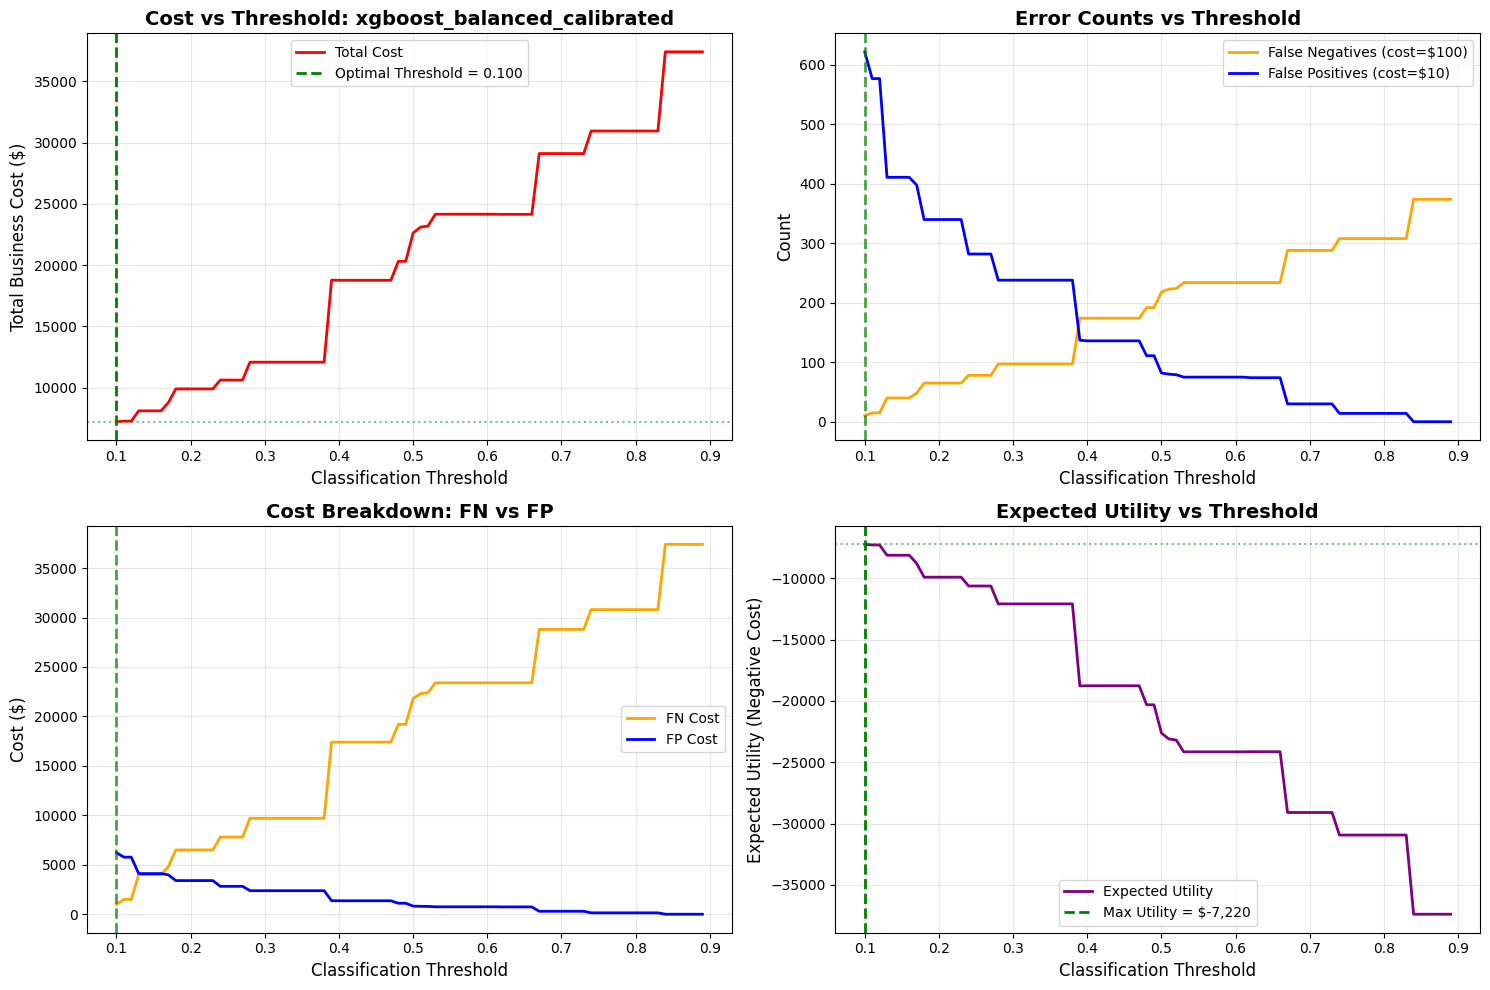

Saved: ..\deliverables\plots\day4\xgboost_balanced_calibrated_cost_curve.png

CALIBRATED MODEL RESULTS:
  Optimal Threshold: 0.100
  Total Cost: $7,220
  False Negatives: 10
  False Positives: 622


In [77]:
# Optimize threshold on CALIBRATED probabilities
print(f"Threshold Optimization on Calibrated Probabilities")

cost_fig_cal, optimal_result_cal = plot_cost_curve(
    y_test.values, best_proba, 
    model_name=f"{model_name}_calibrated",
    save_path=plots_dir / f'{model_name}_calibrated_cost_curve.png'
)
plt.show()
print(f"Saved: {plots_dir / f'{model_name}_calibrated_cost_curve.png'}")

# Print custom summary (don't use print_threshold_summary for calibrated models)
print(f"\nCALIBRATED MODEL RESULTS:")
print(f"  Optimal Threshold: {optimal_result_cal['optimal_threshold']:.3f}")
print(f"  Total Cost: ${optimal_result_cal['optimal_cost']:,.0f}")
print(f"  False Negatives: {optimal_result_cal['optimal_fn']}")
print(f"  False Positives: {optimal_result_cal['optimal_fp']}")

### Calibration vs Uncalibrated Comparison

**Key Insight**: After calibration, the probability scale changes, so threshold=0.5 is not directly comparable between calibrated and uncalibrated models.

The fair comparison is:
- **Baseline (uncalibrated at 0.5)** vs **Calibrated (at optimal threshold)**

In [78]:
# Compare: Baseline vs Optimal Thresholds (both calibrated and uncalibrated)
print(f"FAIR COMPARISON - Baseline vs Optimized Models")

print(f"\n1. BASELINE (Uncalibrated at threshold=0.5):")
print(f"     Cost: ${baseline_cost['total_cost']:,}")
print(f"     FN: {baseline_cost['false_negatives']} | FP: {baseline_cost['false_positives']}")

print(f"\n2. OPTIMIZED CALIBRATED (threshold={optimal_result_cal['optimal_threshold']:.3f}):")
print(f"     Cost: ${optimal_result_cal['optimal_cost']:,}")
print(f"     FN: {optimal_result_cal['optimal_fn']} | FP: {optimal_result_cal['optimal_fp']}")
savings_cal = baseline_cost['total_cost'] - optimal_result_cal['optimal_cost']
print(f"     Savings vs Baseline: ${savings_cal:,} ({savings_cal/baseline_cost['total_cost']*100:.1f}%)")

FAIR COMPARISON - Baseline vs Optimized Models

1. BASELINE (Uncalibrated at threshold=0.5):
     Cost: $7,310
     FN: 18 | FP: 551

2. OPTIMIZED CALIBRATED (threshold=0.100):
     Cost: $7,220.0
     FN: 10 | FP: 622
     Savings vs Baseline: $90.0 (1.2%)


## Summary and MLflow Logging

In [43]:
# Print final summary
print(f"DAY 4 COMPLETE - SUMMARY")

print(f"\n1. SHAP Explainability:")
print(f"   Top Feature: {top_features[0][0]}")
print(f"   Mean |SHAP|: {top_features[0][1]:.4f}")

print(f"\n2. Calibration:")
print(f"   Best Method: {best_method.upper()}")
print(f"   Brier Score: {proper_uncal_metrics['brier_score']:.4f} → {proper_platt_metrics['brier_score'] if best_method == 'platt' else proper_isotonic_metrics['brier_score']:.4f}")
print(f"   ECE: {proper_uncal_metrics['ece']:.4f} → {proper_platt_metrics['ece'] if best_method == 'platt' else proper_isotonic_metrics['ece']:.4f}")

print(f"\n3. Threshold Optimization:")
print(f"   Uncalibrated: Optimal = {optimal_result_uncal['optimal_threshold']:.3f}, Cost = ${optimal_result_uncal['optimal_cost']:,}")
print(f"   Calibrated:   Optimal = {optimal_result_cal['optimal_threshold']:.3f}, Cost = ${optimal_result_cal['optimal_cost']:,}")

print(f"\n4. Cost Improvement:")
baseline_cost_val = baseline_cost['total_cost']
# Use calibrated model as best cost (more trustworthy probabilities)
best_cost = optimal_result_cal['optimal_cost']
cost_savings = baseline_cost_val - best_cost
improvement_pct = (cost_savings / baseline_cost_val) * 100
print(f"   Baseline (threshold=0.5): ${baseline_cost_val:,}")
print(f"   Best (Calibrated): ${best_cost:,}")
print(f"   Savings: ${cost_savings:,} ({improvement_pct:.1f}% improvement)")
print(f"   Note: Using calibrated model for production (trustworthy probabilities)")
print(f"\n5. Reproducibility:")
print(f"   Random State: {RANDOM_STATE}")
print(f"   All results are deterministic with fixed random seed")

DAY 4 COMPLETE - SUMMARY

1. SHAP Explainability:
   Top Feature: cat__Contract_Two year
   Mean |SHAP|: 0.3529

2. Calibration:
   Best Method: ISOTONIC
   Brier Score: 0.2379 → 0.1427
   ECE: 0.2961 → 0.0334

3. Threshold Optimization:
   Uncalibrated: Optimal = 0.430, Cost = $6,980.0
   Calibrated:   Optimal = 0.100, Cost = $7,220.0

4. Cost Improvement:
   Baseline (threshold=0.5): $7,310
   Best (Calibrated): $7,220.0
   Savings: $90.0 (1.2% improvement)
   Note: Using calibrated model for production (trustworthy probabilities)

5. Reproducibility:
   Random State: 42
   All results are deterministic with fixed random seed


In [44]:
# Log to MLflow
with mlflow.start_run(run_name=f"Day4_01_{model_name}_trustworthy"):
    # Set tags
    mlflow.set_tags({
        'day': 'day4',
        'task': 'explainability_calibration_threshold',
        'model_name': model_name,
        'optimization_focus': 'trustworthiness',
        'pipeline_stage': 'production_ready'
    })
    
    # Log params
    mlflow.log_params({
        'model_name': model_name,
        'random_state': RANDOM_STATE,
        'best_calibration_method': best_method,
        'optimal_threshold_uncalibrated': optimal_result_uncal['optimal_threshold'],
        'optimal_threshold_calibrated': optimal_result_cal['optimal_threshold']
    })
    
    # Log SHAP artifacts
    mlflow.log_artifact(str(summary_plot_path), artifact_path="shap_analysis")
    mlflow.log_artifact(str(bar_plot_path), artifact_path="shap_analysis")
    
    # Log top SHAP features
    for i, (feature, importance) in enumerate(top_features[:5], 1):
        mlflow.log_param(f"shap_top{i}_feature", feature)
        mlflow.log_metric(f"shap_top{i}_importance", importance)
    
    # Log calibration metrics
    mlflow.log_metric("calibration_brier_uncalibrated", proper_uncal_metrics['brier_score'])
    mlflow.log_metric("calibration_brier_platt", proper_platt_metrics['brier_score'])
    mlflow.log_metric("calibration_brier_isotonic", proper_isotonic_metrics['brier_score'])
    mlflow.log_metric("calibration_ece_uncalibrated", proper_uncal_metrics['ece'])
    mlflow.log_metric("calibration_ece_platt", proper_platt_metrics['ece'])
    mlflow.log_metric("calibration_ece_isotonic", proper_isotonic_metrics['ece'])
    
    # Log calibration artifacts
    mlflow.log_artifact(str(plots_dir / f'{model_name}_calibration_platt_proper.png'), 
                       artifact_path="calibration")
    mlflow.log_artifact(str(plots_dir / f'{model_name}_calibration_isotonic_proper.png'), 
                       artifact_path="calibration")
    
    # Log threshold optimization results
    mlflow.log_metric("optimal_threshold_uncalibrated", optimal_result_uncal['optimal_threshold'])
    mlflow.log_metric("optimal_threshold_calibrated", optimal_result_cal['optimal_threshold'])
    mlflow.log_metric("optimal_cost_uncalibrated", optimal_result_uncal['optimal_cost'])
    mlflow.log_metric("optimal_cost_calibrated", optimal_result_cal['optimal_cost'])
    mlflow.log_metric("optimal_fn_uncalibrated", optimal_result_uncal['optimal_fn'])
    mlflow.log_metric("optimal_fn_calibrated", optimal_result_cal['optimal_fn'])
    mlflow.log_metric("optimal_fp_uncalibrated", optimal_result_uncal['optimal_fp'])
    mlflow.log_metric("optimal_fp_calibrated", optimal_result_cal['optimal_fp'])
    mlflow.log_metric("baseline_cost_threshold_0.5", baseline_cost_val)
    mlflow.log_metric("baseline_pr_auc", baseline_metrics['pr_auc'])
    
    # Log threshold artifacts
    mlflow.log_artifact(str(plots_dir / f'{model_name}_uncalibrated_cost_curve.png'), 
                       artifact_path="threshold_optimization")
    mlflow.log_artifact(str(plots_dir / f'{model_name}_calibrated_cost_curve.png'), 
                       artifact_path="threshold_optimization")
    
    # Log calibrated model
    mlflow.sklearn.log_model(best_model, "calibrated_model")
    
    print(f"\n✅ All results logged to MLflow experiment: {MLFLOW_EXPERIMENT_NAME}")
    print(f"   Run MLflow UI: mlflow ui --port 5000")

2025/11/28 10:46:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/28 10:46:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/28 10:46:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ All results logged to MLflow experiment: telco-churn-day4-trustworthy
   Run MLflow UI: mlflow ui --port 5000
